## Training the Neural Ratio Estimator on Strong Lensing Simulations
This notebook trains a neural ratio estimator (NRE) to perform simulation-based inference of cosmological parameters, the dark energy equation-of-state ($w_0$) and matter density ($\Omega_m$) from simulated strong gravitational lensing images. The NRE is trained as a binary classifier to distinguish joint samples $(x, \theta) \sim p(x, \theta)$ from marginal samples $(x, \theta') \sim p(x)p(\theta)$, learning to approximate the likelihood-to-evidence ratio $\log r(x, \theta) = \log p(x|\theta)/p(x)$. The training set consists of 2 million 32×32 single-band lensing images with associated cosmological parameters ($w_0$, $\Omega_m$) and astrophysical parameters (lens/source redshifts, velocity dispersion).


In [1]:
!export LD_LIBRARY_PATH=/opt/conda/lib
!export XLA_FLAGS=--xla_gpu_cuda_data_dir=/home/jarugula/cuda_data_dir
!export PATH=/usr/local/cuda-11.7/bin:${PATH}

In [2]:
# Import necessary packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.metrics import auc, roc_curve
from scipy.stats import uniform, norm
import matplotlib.pyplot as plt
import random
import pandas as pd

import os
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Reshape,Conv1D,Flatten,Dense, Lambda
from tensorflow.keras.models import Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TerminateOnNaN
physical_devices = tf.config.list_physical_devices('GPU')
try:
  tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
  pass
from sklearn.utils import shuffle
AUTOTUNE = tf.data.AUTOTUNE
from sklearn.preprocessing import StandardScaler
import tqdm
import gc
import wandb
cols = ["#DB4437", "#4285F4", "#F4B400", "#0F9D58", "purple", "goldenrod", "peru",
        "coral", "turquoise", 'gray', 'navy', 'm', 'darkgreen', 'fuchsia', 'steelblue']

os.environ['PATH']=os.environ['PATH']+':/usr/local/cuda/bin'
os.environ['XLA_FLAGS']='--xla_gpu_cuda_data_dir=/home/jarugula/cuda_data_dir'

2025-06-06 20:46:07.484838: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-06-06 20:46:11.003468: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-06-06 20:46:19.000443: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-06 20:46:19.560595: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA n

### Plotting functions

In [ ]:
def get_roc_auc(y_test, x_test, aparm_test, theta_test, model):
    '''
    Compute ROC curve and AUC score for the classifier.

    Inputs:
    y_test: True labels (1 = joint, 0 = marginal) for the test set
    x_test: List of strong lens images 
    aparm_test: List of astro parameters 
    theta_test: List of thetas (w and om) both shuffled and unshuffled
    model: The model for testing

    Returns:
    fpr: False positive Rate
    tpr: true Positive Rate
    thresholds: to calculate fpr and tpr
    roc_auc: The AUC score
    '''
    y_pred = model.predict([x_test, aparm_test, theta_test])
    y_pred_prob = tf.nn.sigmoid(y_pred) # probability that sample is from p(x,theta)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
    roc_auc_value = auc(fpr, tpr)
    y_pred_prob = y_pred_prob[:,0].numpy()
    return fpr, tpr, thresholds, roc_auc_value, y_pred_prob

def plot_roc_curve(fpr, tpr, roc_auc, outname='roc_curve.png'):
    '''
    Plot and save the ROC curve.

    Inputs:
    fpr: False positive rates (from get_roc_auc)
    tpr: True positive rates (from get_roc_auc)
    roc_auc: Scalar AUC value to annotate on the plot
    outname: Output file prefix.
    '''
    plt.figure(figsize=(6, 6))
    lw = 1.2
    plt.plot(fpr, tpr, lw=lw, ls='--')

    plt.plot([0, 1], [0, 1], color='k', lw=lw, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])

    plt.text(0.7, 0.05, 'AUC = {}'.format(np.round(roc_auc, 2)), fontsize = 16, 
            bbox = dict(facecolor = 'grey', alpha = 0.2))

    plt.tick_params(axis='both', which='both', labelsize=14)
    plt.xlabel('False Positive Rate', fontsize=18)
    plt.ylabel('True Positive Rate', fontsize=18)
    plt.savefig('/deepskieslab/stronglensing/hsbi/models/plots/'+outname+'_roc.pdf', dpi=300)
    plt.show()
    return

def plot_prob_distribution(y_test, y_pred_prob, outname='prob_distribution.png'):
    '''
    Plot the classifier output probability distributions for joint (label=1) and marginal (label=0) samples.
    A well-trained NRE classifier should show two separated peaks near 0 and 1.

    Inputs:
    y_test: True binary labels (1 = joint, 0 = marginal)
    y_pred_prob: Sigmoid-transformed model outputs. 
    outname: Output file prefix.
    '''
    plt.figure(figsize=(10, 6))
    plt.yscale('log')
    plt.hist(y_pred_prob[y_test == 1], bins=100, histtype='step', color='k', lw=1, label='Label = 1')
    plt.hist(y_pred_prob[y_test == 0], bins=100, histtype='step', color='r', lw=1, label='Label = 0')
    plt.xlabel('Prob of {x,cosmology} ~ joint distribution', fontsize=18)
    plt.ylabel('Counts', fontsize=18)
    plt.tick_params(axis='both', which='both', labelsize=14)
    plt.legend(fontsize=18)
    plt.savefig('/deepskieslab/stronglensing/hsbi/models/plots/'+outname+'_prob_dist.pdf', dpi=300)
    plt.show()
    return


def plot_training_dist(metadata, outname):
    '''
    Plot histograms of the parameter distributions (w0, Om0, zl, zs, sigma_v, theta_E).

    Inputs:
    metadata: DataFrame containing simulation metadata with parameter columns
    outname: Output file prefix.
    '''
    w_column_name = "w0-g" # Dark energy equation-of-state parameter 
    om_column_name = 'Om0-g'
    zl_column_name = 'PLANE_1-REDSHIFT-g'
    zs_column_name = 'PLANE_2-REDSHIFT-g'
    v_column_name = 'PLANE_1-OBJECT_1-MASS_PROFILE_1-sigma_v-g'
    radius_column_name = "PLANE_1-OBJECT_1-MASS_PROFILE_1-theta_E-g" 

    columns = [w_column_name, om_column_name, zl_column_name, zs_column_name, v_column_name, radius_column_name]
    x_labels = ['$w_{0}$', '$\Omega_{0}$', '$z_{l}$', '$z_s$', '$\sigma_{v}$', '$\Theta_{E}$']

    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    
    for idx, col in enumerate(columns):
        row = idx // 3
        col_idx = idx % 3
        axs[row, col_idx].hist(metadata[col], bins=30, edgecolor='black')
        axs[row, col_idx].tick_params(axis='both', which='major', labelsize=15)
        # axs[row, col_idx].set_title(x_labels[idx], fontsize=20)
        axs[row, col_idx].set_xlabel(x_labels[idx], fontsize=20)

    plt.tight_layout()
    plt.savefig('/deepskieslab/stronglensing/hsbi/datasets/train_data/plots/'+outname+'_training_dist.pdf', dpi=300)
    plt.show()

    return 

def plot_train_val(history, train_col, val_col, outname):
    '''
    Plot train vs. validation metric curves with their difference on a lower panel.

    Inputs:
    history: Training history DataFrame (loaded from CSV)
    train_col: Column name for the training metric (e.g. 'loss', 'acc')
    val_col: Column name for the validation metric (e.g. 'val_loss', 'val_acc')
    outname: Output file prefix.
    '''
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True, sharey=False, height_ratios=[0.7,0.3], gridspec_kw={'hspace': 0.0, 'wspace': 0.0})
    ax1.plot(history_df[train_col], label=f'Train', linestyle='-')
    ax1.plot(history_df[val_col], label=f'Validation', linestyle='--')
    ax1.set_title(train_col, fontsize=24)
    ax1.set_ylabel(train_col, fontsize=18)
    ax1.legend(fontsize=18)
    ax1.tick_params(labelsize=18)
    # plot the difference between train and val loss
    ax2.plot(history_df[train_col] - history_df[val_col], linestyle='-', color='grey', label='Train - Val')
    ax2.legend(fontsize=18)
    ax2.tick_params(labelsize=18)
    # plot a line at on the y axis
    ax2.axhline(0, color='red', linestyle='--')
    ax2.set_xlabel('Epoch', fontsize=18)
    ax2.set_ylabel('Train - Val', fontsize=18)
    plt.savefig('/deepskieslab/stronglensing/hsbi/models/plots/'+outname+'_'+train_col+'_train_val.pdf', dpi=300)
    plt.show()
    return 


### Data import and pre-processing

In [ ]:
output_name = "entire_region_narrowprior"
data_path = '/deepskieslab/stronglensing/hsbi/datasets/train_data/'
image_dir1 = 'entire_range_narrowprior_copy1'
image_dir2 = 'entire_range_narrowprior_copy2'
image_dir3 = 'entire_range_narrowprior_copy3'
image_dir4 = 'entire_range_narrowprior_copy4'

In [ ]:
# Read the images and metadata
images1 = np.load(data_path+image_dir1+'/CONFIGURATION_1_images.npy', allow_pickle=True)
metadata1 = pd.read_csv(data_path+image_dir1+'/CONFIGURATION_1_metadata.csv')
images2 = np.load(data_path+image_dir2+'/CONFIGURATION_1_images.npy', allow_pickle=True)
metadata2 = pd.read_csv(data_path+image_dir2+'/CONFIGURATION_1_metadata.csv')
images3 = np.load(data_path+image_dir3+'/CONFIGURATION_1_images.npy', allow_pickle=True)
metadata3 = pd.read_csv(data_path+image_dir3+'/CONFIGURATION_1_metadata.csv')
images4 = np.load(data_path+image_dir4+'/CONFIGURATION_1_images.npy', allow_pickle=True)
metadata4 = pd.read_csv(data_path+image_dir4+'/CONFIGURATION_1_metadata.csv')

In [ ]:
# concatenate the images and metadata
images = np.concatenate((images1, images2, images3, images4), axis=0)
metadata = pd.concat([metadata1, metadata2, metadata3, metadata4], axis=0)

del images1, images2, images3, images4, metadata1, metadata2, metadata3, metadata4
gc.collect()

20

In [8]:
print(len(metadata), len(images))

2000000 2000000


In [ ]:
w_column_name = "w0-g" # Dark energy equation-of-state parameter 
om_column_name = 'Om0-g' # Dark matter density parameter
zl_column_name = 'PLANE_1-REDSHIFT-g' # Lens redshift
zs_column_name = 'PLANE_2-REDSHIFT-g' # Source redshift
v_column_name = 'PLANE_1-OBJECT_1-MASS_PROFILE_1-sigma_v-g' # Velocity dispersion of the lens
radius_column_name = "PLANE_1-OBJECT_1-MASS_PROFILE_1-theta_E-g" # Einstein radius

In [10]:
columns = [w_column_name, om_column_name, zl_column_name, zs_column_name, v_column_name, radius_column_name]
x_labels = ['$w_{0}$', '$\Omega_{0}$', '$z_{l}$', '$z_s$', '$\sigma_{v}$', '$\Theta_{E}$']

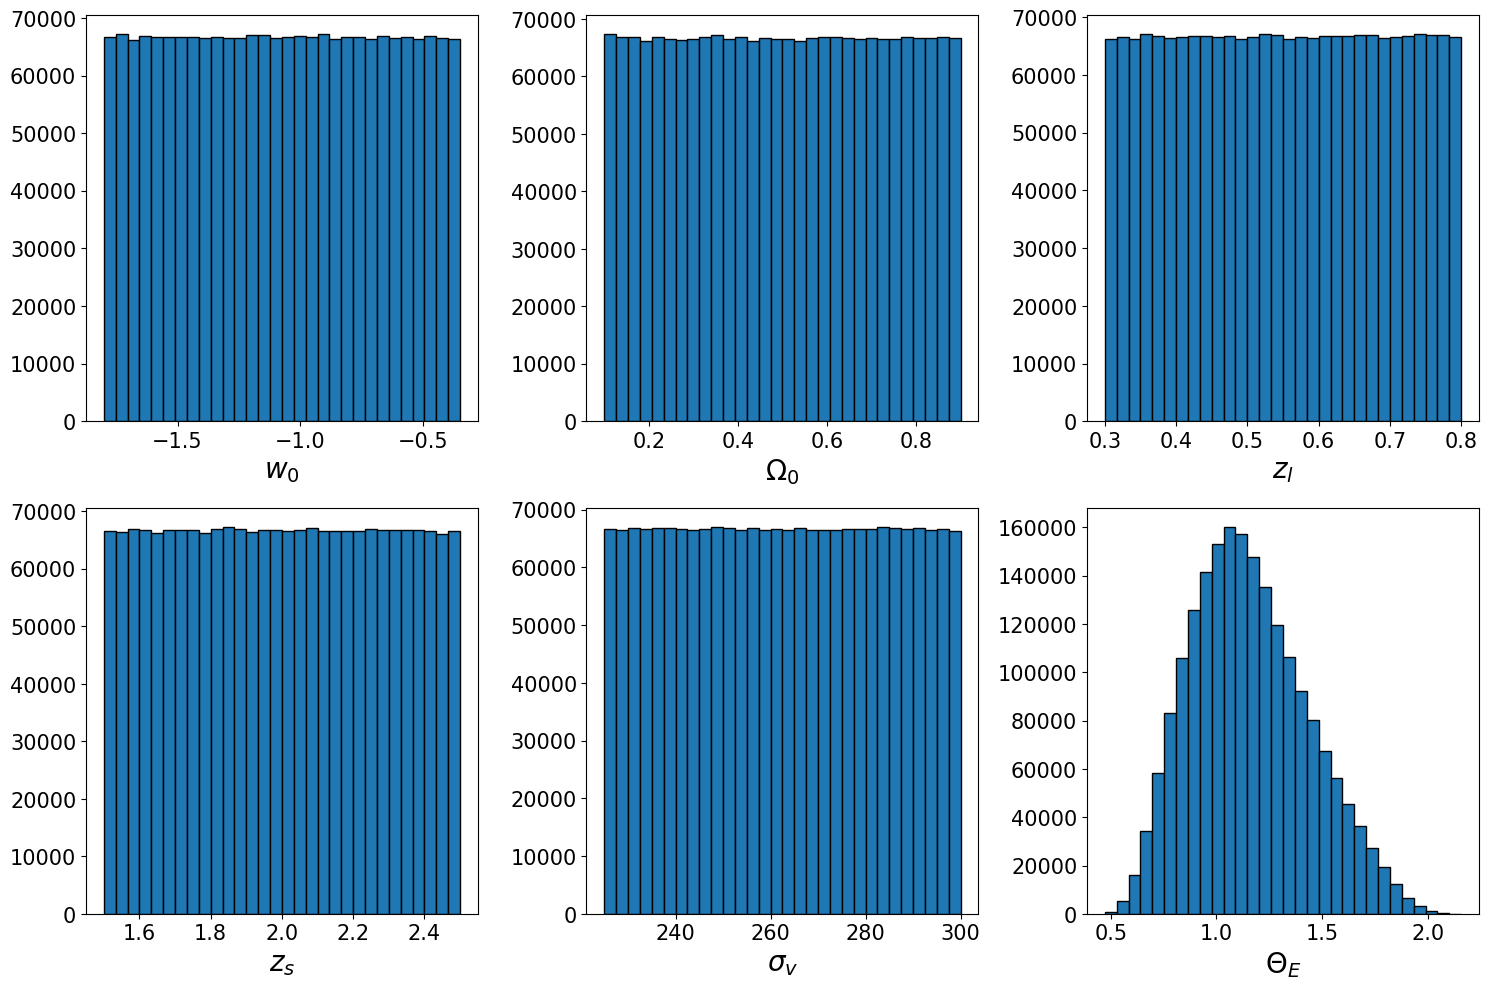

In [ ]:
# plot the histograms of the parameter distributions

fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    
for idx, col in enumerate(columns):
    row = idx // 3
    col_idx = idx % 3
    axs[row, col_idx].hist(metadata[col], bins=30, edgecolor='black')
    axs[row, col_idx].tick_params(axis='both', which='major', labelsize=15)
    # axs[row, col_idx].set_title(x_labels[idx], fontsize=20)
    axs[row, col_idx].set_xlabel(x_labels[idx], fontsize=20)


plt.tight_layout()
plt.show()
plt.close()

In [13]:
# print min and max of om0_g
print(metadata['Om0-g'].min(), metadata['Om0-g'].max())
print(metadata['w0-g'].min(), metadata['w0-g'].max())

0.1000008194072787 0.8999994673453076
-1.7999999017806212 -0.3500020724248367


In [ ]:
# Reshape the images to have the channel dimension last (NHWC format)
images = np.einsum('lkij->lijk',images)
print(images.shape)

(2000000, 32, 32, 1)


In [ ]:
# theta: target cosmological parameters (w0, Om0) - the parameters we want to infer posteriors over
# aparms: astrophysical nuisance parameters (zl, zs, sigma_v) - conditioned on but not inferred
theta = metadata[[w_column_name,om_column_name]].to_numpy().astype(np.float32)
aparms = metadata[[zl_column_name, zs_column_name, v_column_name]].to_numpy().astype(np.float32)

In [16]:
print(aparms.shape)

(2000000, 3)


In [ ]:
# Normalize each image by its total flux.
# The scale factor (edge_size^2) preserves the mean pixel value.
edge_size = images.shape[1]
images = edge_size*edge_size*(images/np.sum(images, axis=(1,2), keepdims=True))
images = images.reshape(images.shape[0], -1)
images = images.reshape(images.shape[0], edge_size, edge_size, 1)

In [18]:
images.shape

(2000000, 32, 32, 1)

### Split the data into train and test

In [ ]:
# Split into train and test
x_train , x_test, theta_train, theta_test, aparms_train, aparms_test, y_train, y_test = train_test_split(images, theta, aparms, np.ones_like(theta[:,0]), test_size=0.005, random_state=0)

del images
gc.collect()

2140

In [ ]:
# shape of the training and test sets
print(x_train.shape)
print(theta_train.shape)
print(aparms_train.shape)
print(y_train.shape)

print(x_test.shape)
print(y_test.shape)


(1990000, 32, 32, 1)
(1990000, 2)
(1990000, 3)
(1990000,)
(10000, 32, 32, 1)
(10000,)


### Train the Neural network model 

In [ ]:
seed = 128 # random weight initialization
inputs_img = keras.Input(shape=x_train[0].shape)
inputs_aparms = keras.Input(shape=(aparms_train[0].shape)) # zl, zs, v
inputs_theta = keras.Input(shape=(theta_train[0].shape)) # w and om are the parameters
custom_initializer = tf.keras.initializers.he_uniform(seed=seed)

# Entry block for ResNet
x = layers.BatchNormalization()(inputs_img)
x = layers.Conv2D(128/8, 3, strides=2, padding="same",kernel_initializer=custom_initializer)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)

previous_block_activation = x  # Set aside residual

for size in [256/8, 512/8, 728/8]:
    x = layers.Activation("relu")(x)
    x = layers.Conv2D(size, 3, padding="same",kernel_initializer=custom_initializer)(x)
    x = layers.BatchNormalization()(x)

    x = layers.Activation("relu")(x)
    x = layers.Conv2D(size, 3, padding="same",kernel_initializer=custom_initializer)(x)
    x = layers.BatchNormalization()(x)

    x = layers.MaxPooling2D(3, strides=2, padding="same")(x)

    # Project residual
    residual = layers.Conv2D(size, 1, strides=2, padding="same",kernel_initializer=custom_initializer)(
        previous_block_activation
    )
    x = layers.add([x, residual])  # Add back residual
    previous_block_activation = x  # Set aside next residual

x = layers.SeparableConv2D(1024/16, 3, padding="same",kernel_initializer=custom_initializer)(x) #64
x = layers.Activation("relu")(x)
x = layers.GlobalAveragePooling2D()(x)

# convert aparms to same shape as x and concatenate
aparms_rep = layers.BatchNormalization()(inputs_aparms)
aparms_rep = layers.Dense(64, kernel_initializer=custom_initializer)(aparms_rep)
theta_rep= layers.BatchNormalization()(inputs_theta)
theta_rep = layers.Dense(64, kernel_initializer=custom_initializer)(theta_rep)

# concatenate the image features and the astro parameter features
x = tf.concat([x, aparms_rep, theta_rep], axis=-1)

# Fully connected layers
x = layers.Dense(192, kernel_regularizer=tf.keras.regularizers.l2(0.01),kernel_initializer=custom_initializer)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.1)(x)

x = layers.Dense(64, kernel_regularizer=tf.keras.regularizers.l2(0.01),kernel_initializer=custom_initializer)(x)
x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)
x = layers.Dropout(0.1)(x)

# Outputs the log likelihood-to-evidence ratio : log p(x|w,om)/p(x)
outputs = layers.Dense(1)(x) 

# Create the model
model = keras.Model(inputs=[inputs_img,inputs_aparms,inputs_theta], outputs=outputs)

model.summary()

2025-05-31 19:39:50.222632: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-31 19:39:50.223107: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-05-31 19:39:50.223385: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 32, 32, 1)]          0         []                            
                                                                                                  
 batch_normalization (Batch  (None, 32, 32, 1)            4         ['input_1[0][0]']             
 Normalization)                                                                                   
                                                                                                  
 conv2d (Conv2D)             (None, 16, 16, 16)           160       ['batch_normalization[0][0]'] 
                                                                                                  
 batch_normalization_1 (Bat  (None, 16, 16, 16)           64        ['conv2d[0][0]']          

In [ ]:
# Implements the NRE binary classification objective.
# Positive class (label=1): (x, theta) pairs drawn from the joint p(x, theta).
# Negative class (label=0): (x, theta') pairs where theta' is drawn uniformly from the prior,
#   approximating samples from the marginal p(x)p(theta).
# The network output approximates the log likelihood-to-evidence ratio: log r(x,theta) = log p(x|theta)/p(x).

class SNREmodel(keras.Model):
    def __init__(self, model, **kwargs):
        super(SNREmodel, self).__init__(**kwargs)
        self.model = model

    def train_step(self, data):
        image, aparm, theta = data[0]
        labels = tf.ones_like(theta[:,0]) # generate class label=1 for p(x,theta)

        # shuffle the theta to generate p(x)p(theta) which is assigned a class label=0
        images_shuffle = tf.identity(image)
        aparms_shuffle = tf.identity(aparm)
        theta_shape = tf.shape(theta)
        theta_shuffle0 = tf.random.uniform(shape=(theta_shape[0],), minval=-2.0, maxval=-0.4)
        theta_shuffle1 = tf.random.uniform(shape=(theta_shape[0],), minval=0.1, maxval=1.0)
        theta_shuffle = tf.stack([theta_shuffle0, theta_shuffle1], axis=1)
    
        labels_shuffle = tf.zeros_like(theta_shuffle[:,0])

        # concatenate the original and shuffled data to form a batch with both positive and negative samples

        image = tf.concat([image, images_shuffle], axis=0)
        aparm = tf.concat([aparm, aparms_shuffle], axis=0)
        theta = tf.concat([theta, theta_shuffle], axis=0) 
        labels = tf.concat([labels, labels_shuffle], axis=0)

        index = tf.range(tf.shape(image)[0])
        index = tf.random.shuffle(index)
        image = tf.gather(image, index)
        aparm = tf.gather(aparm, index)
        theta = tf.gather(theta, index)
        labels = tf.gather(labels, index)

        with tf.GradientTape() as tape:
            predictions = self.model([image, aparm, theta], training=True)
            # use a binary cross entropy loss
            loss = self.compiled_loss(labels, predictions)
        # compute gradients and update weights
        trainable_vars = self.model.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))
        self.compiled_metrics.update_state(labels, predictions)
        return {m.name: m.result() for m in self.metrics}
    
    def test_step(self, data):
        image, aparm, theta = data[0]
        labels = tf.ones_like(theta[:,0])

        images_shuffle = tf.identity(image)
        aparms_shuffle = tf.identity(aparm)
        theta_shape = tf.shape(theta)
        theta_shuffle0 = tf.random.uniform(shape=(theta_shape[0],), minval=-2.0, maxval=-0.4)
        theta_shuffle1 = tf.random.uniform(shape=(theta_shape[0],), minval=0.1, maxval=1.0)
        theta_shuffle = tf.stack([theta_shuffle0, theta_shuffle1], axis=1)
        
        labels_shuffle = tf.zeros_like(theta_shuffle[:,0])

        image = tf.concat([image, images_shuffle], axis=0)
        aparm = tf.concat([aparm, aparms_shuffle], axis=0)
        theta = tf.concat([theta, theta_shuffle], axis=0)
        labels = tf.concat([labels, labels_shuffle], axis=0)

        index = tf.range(tf.shape(image)[0])
        index = tf.random.shuffle(index)
        image = tf.gather(image, index)
        aparm = tf.gather(aparm, index)
        theta = tf.gather(theta, index)
        labels = tf.gather(labels, index)

        predictions = self.model([image, aparm, theta], training=False)
        loss = self.compiled_loss(labels, predictions)
        for metric in self.metrics:
            if metric.name == 'loss':
                metric.update_state(loss)
            else:
                metric.update_state(labels, predictions)
        return {m.name: m.result() for m in self.metrics}

In [ ]:
# Binary cross-entropy from logits; the final Dense(1) outputs log-odds = log r(x,theta) directly.
# ReduceLROnPlateau decays LR by 10x after 5 stagnant val_loss epochs; EarlyStopping
# restores best weights and halts after 20 epochs without improvement.
snre_model = SNREmodel(model)
snre_model.compile(loss=tf.keras.losses.BinaryCrossentropy(from_logits=True), 
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-2),
              metrics=[keras.metrics.BinaryAccuracy(name="acc"), keras.metrics.AUC(name="auc")])

callbacks_ = [tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True), 
              tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.1,patience=5, min_lr=1e-6)]

history = snre_model.fit([x_train, aparms_train, theta_train], validation_split=0.2, epochs=100, batch_size=1024, callbacks=callbacks_)

trained_model = snre_model.model


In [ ]:
model = trained_model

In [28]:
# save the model
model.save(f'/deepskieslab/stronglensing/hsbi/models/{output_name}.keras')

In [29]:
# save model history
history_df = pd.DataFrame(history.history)
history_df.to_csv(f'/deepskieslab/stronglensing/hsbi/models/{output_name}_history.csv', index=False)

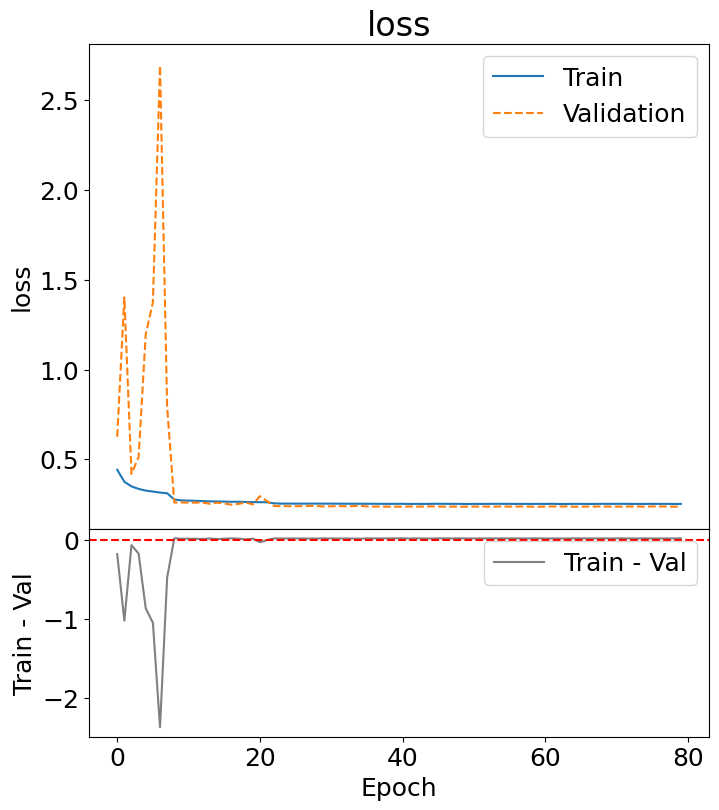

In [ ]:
# plot the training and validation loss curves
plot_train_val(history_df, 'loss', 'val_loss', output_name)

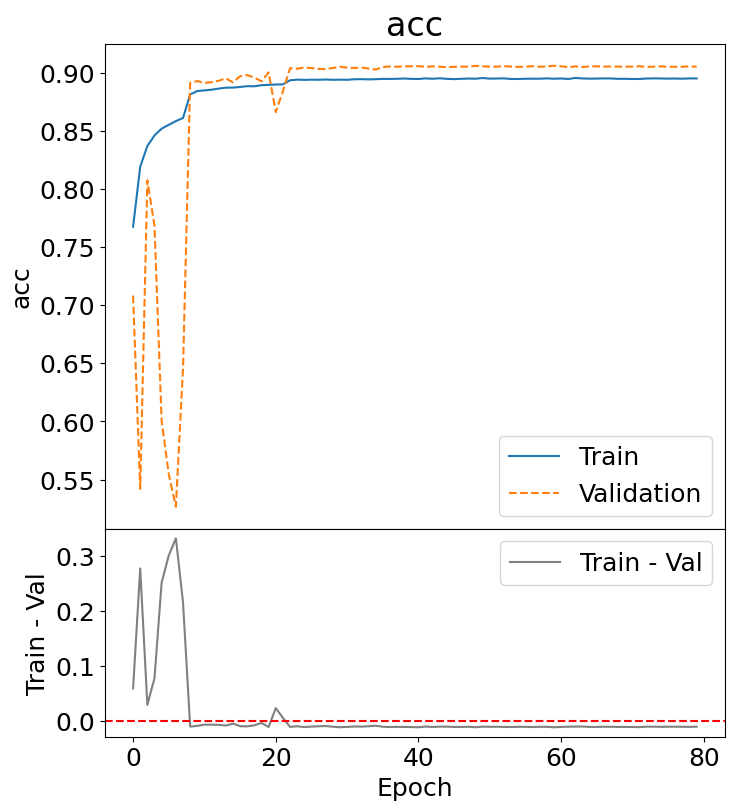

In [ ]:
# plot the training and validation accuracy curves
plot_train_val(history_df, 'acc', 'val_acc', output_name)

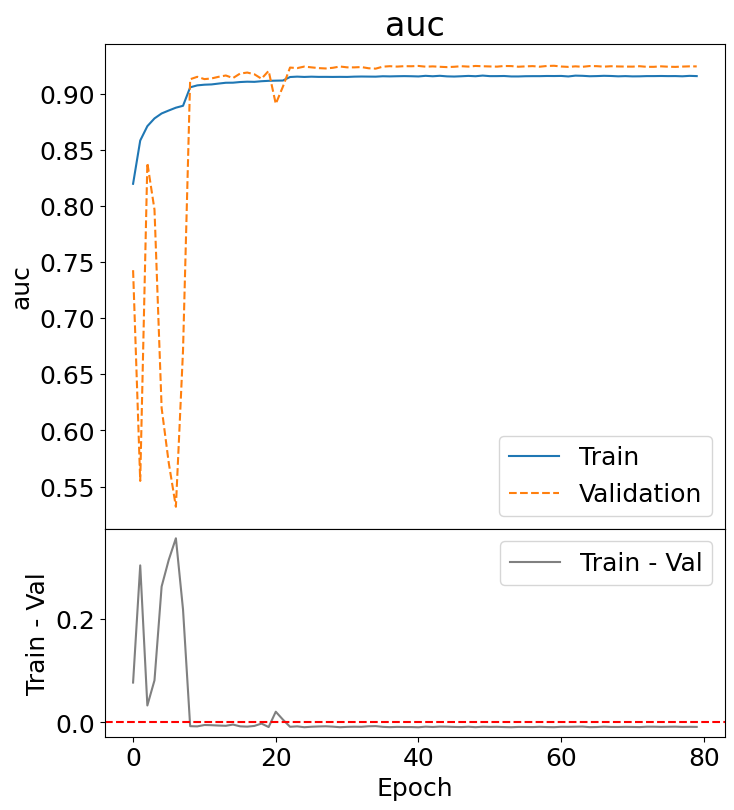

In [ ]:
# plot the training and validation AUC curves
plot_train_val(history_df, 'auc', 'val_auc', output_name)

## Evaluate the model on the training data

In [22]:
# read the model
model = keras.models.load_model(f'/deepskieslab/stronglensing/hsbi/models/{output_name}.keras')

2025-06-06 20:47:05.109188: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-06 20:47:05.109657: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-06 20:47:05.109892: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [23]:
# select random 10000 samples from the train set
random_indices = np.random.choice(len(x_test), size=10000, replace=False)
x_train = x_train[random_indices]
theta_train = theta_train[random_indices]
aparms_train = aparms_train[random_indices]
y_train = y_train[random_indices]

In [ ]:
# Manually construct a balanced evaluation set matching the train_step pairing logic:
# positive pairs retain true (x, theta); negative pairs keep x but replace theta with
# a draw from the prior, producing marginal samples for the label=0 class.
y_train_noshuffle = np.ones(len(theta_train[:,0]))
images_shuffle = np.copy(x_train)
aparms_shuffle = np.copy(aparms_train)
theta_shape = tf.shape(theta_train)
theta_shuffle0 = tf.random.uniform(shape=(theta_shape[0],), minval=-2.0, maxval=-0.4)
theta_shuffle1 = tf.random.uniform(shape=(theta_shape[0],), minval=0.1, maxval=1.0)
theta_train_shuffle = tf.stack([theta_shuffle0, theta_shuffle1], axis=1)
y_train_shuffle = np.zeros(len(theta_train_shuffle[:,0]))

x_train_concat = np.concatenate((x_train, images_shuffle), axis=0)
aparms_train_concat = np.concatenate((aparms_train, aparms_shuffle), axis=0)
theta_train_concat = np.concatenate((theta_train, theta_train_shuffle), axis=0)
y_train_concat = np.concatenate((y_train_noshuffle, y_train_shuffle), axis=0)

In [25]:
# shuffle the data
indices = np.arange(len(y_train_concat))
np.random.shuffle(indices)
x_train_concat = x_train_concat[indices]
aparms_train_concat = aparms_train_concat[indices]
theta_train_concat = theta_train_concat[indices]
y_train_concat = y_train_concat[indices]

In [ ]:
# compute the ROC curve and AUC score for the classifier on the training set
fpr, tpr, thresholds, roc_auc, y_pred_prob = get_roc_auc(y_train_concat, x_train_concat, aparms_train_concat, theta_train_concat, model)

2025-06-06 20:47:17.846134: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8906
2025-06-06 20:47:18.638427: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


625/625 [==============================] - 3s 2ms/step


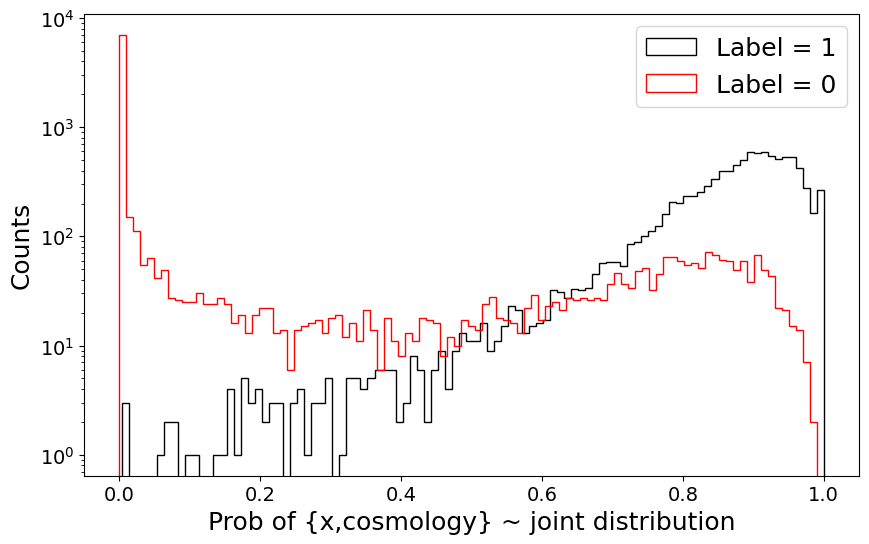

In [ ]:
# plot the probability distribution of the classifier outputs for the training set
plot_prob_distribution(y_train_concat, y_pred_prob, output_name)

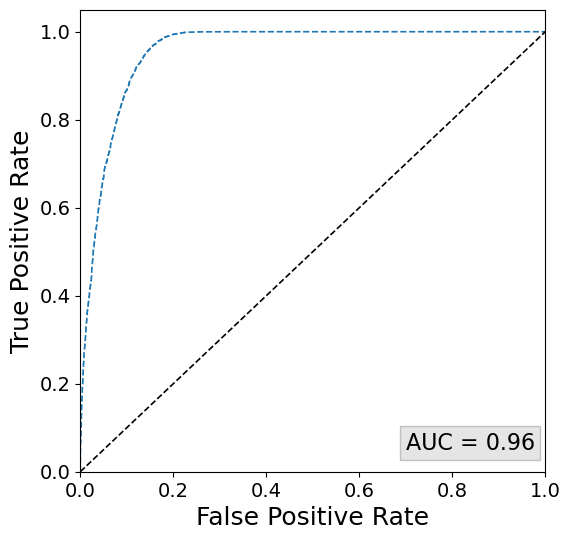

In [ ]:
# plot the ROC curve for the classifier
plot_roc_curve(fpr, tpr, roc_auc, output_name)

## Pre-processing test data

In [25]:
# read the model
model = keras.models.load_model(f'/deepskieslab/stronglensing/hsbi/models/{output_name}.keras')

2025-06-06 20:40:25.283937: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-06 20:40:25.284271: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-06-06 20:40:25.284470: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

In [ ]:
# Same balanced pairing construction as above, applied to the held-out test set.
y_test_noshuffle = np.ones(len(theta_test[:,0]))
images_shuffle = np.copy(x_test)
aparms_shuffle = np.copy(aparms_test)
theta_shape = tf.shape(theta_test)
theta_shuffle0 = tf.random.uniform(shape=(theta_shape[0],), minval=-2.0, maxval=-0.4)
theta_shuffle1 = tf.random.uniform(shape=(theta_shape[0],), minval=0.1, maxval=1.0)
theta_test_shuffle = tf.stack([theta_shuffle0, theta_shuffle1], axis=1)
y_test_shuffle = np.zeros(len(theta_test_shuffle[:,0]))

x_test_concat = np.concatenate((x_test, images_shuffle), axis=0)
aparms_test_concat = np.concatenate((aparms_test, aparms_shuffle), axis=0)
theta_test_concat = np.concatenate((theta_test, theta_test_shuffle), axis=0)
y_test_concat = np.concatenate((y_test_noshuffle, y_test_shuffle), axis=0)

In [30]:
# shuffle the data
indices = np.arange(len(y_test_concat))
np.random.shuffle(indices)
x_test_concat = x_test_concat[indices]
aparms_test_concat = aparms_test_concat[indices]
theta_test_concat = theta_test_concat[indices]
y_test_concat = y_test_concat[indices]

In [31]:
fpr, tpr, thresholds, roc_auc, y_pred_prob = get_roc_auc(y_test_concat, x_test_concat, aparms_test_concat, theta_test_concat, model)

625/625 [==============================] - 1s 2ms/step


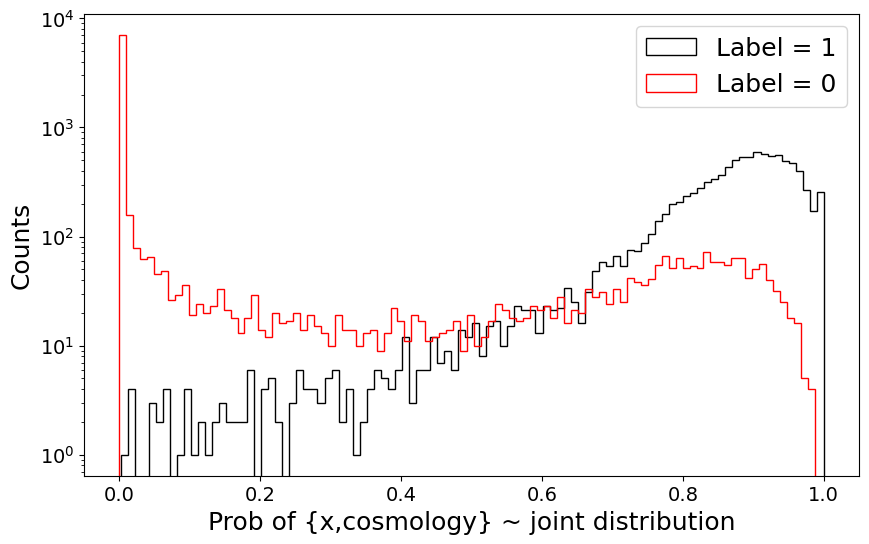

In [32]:
plot_prob_distribution(y_test_concat, y_pred_prob, output_name)

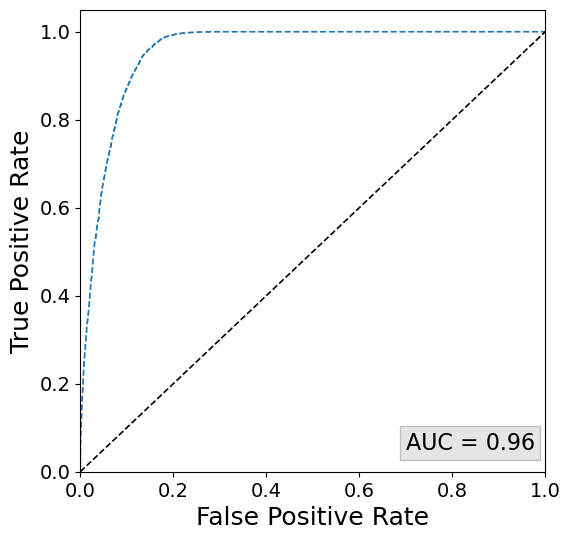

In [33]:
plot_roc_curve(fpr, tpr, roc_auc, output_name)